## 1. What this notebook computes

This notebook is a first look at the universe of the book. It computes no new
physics; it shows, with numbers and pictures, the facts about the eight directions
and the author's metric that every later chapter uses. It

- reads the names of the eight coordinates $x_1, \dots, x_8$ and their signs from a
  file of the Revision record (the computations stored in the folder Revision of
  the repository), and prints which directions are like space and which are like
  time;
- writes the author's metric with the package sympy and checks that its eight
  entries are exactly those that the Revision verifier recorded, that their signs
  are the recorded signs, and that its determinant is $\cos^2 z$;
- shows what happens when the metric function $a_4$ grows: lengths along ordinary
  space grow (inflation) and lengths along the three extra times shrink (deflation),
  while the volume factor stays the same;
- draws four teaching plots and prints a PASS line for every check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 00b (The eight directions and the author's metric: a first look) is the file
`Revision/textbook/notebooks/00b_eight_directions.ipynb` of the repository Dirac_claude.
It reads the names and the signs of the eight coordinates x1 to x8 from the Revision
record, writes the author's metric with sympy, checks that its eight entries, their signs
and its determinant cos^2 z agree with what the Revision verifiers recorded, and draws
four teaching plots: the signs as a heat map, the growing and the shrinking length
factors, the eight length factors as bars, and the volume factor. It needs a computer
with Windows 11, macOS or Linux, an internet connection for the installation, the program
Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 00b_eight_directions.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 00b_eight_directions.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
00b_eight_directions.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/00b.captions.json`
- `Revision/textbook/figures/00b_1_eta_heat_map.png`
- `Revision/textbook/figures/00b_2_scale_factors.png`
- `Revision/textbook/figures/00b_3_length_factors.png`
- `Revision/textbook/figures/00b_4_volume_factor.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the four figure files of this notebook exist
    ALL 14 CHECKS PASSED (notebook 00b)

and the notebook must show 4 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/00b_eight_directions.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 00b_eight_directions.ipynb
      python -m nbconvert --execute --inplace 00b_eight_directions.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" or "KeyError" naming a file below the folder Revision: a file of
  the Revision record is missing or damaged: the repository folder is incomplete. Delete
  the folder Dirac_claude, download it again with the git clone command of Step 3, and
  open the notebook from the new folder.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 00b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 00b (The eight directions and the author's metric: a first look) is the file
# Revision/textbook/notebooks/00b_eight_directions.ipynb of the repository Dirac_claude.
# It reads the names and the signs of the eight coordinates x1 to x8 from the Revision
# record, writes the author's metric with sympy, checks that its eight entries, their
# signs and its determinant cos^2 z agree with what the Revision verifiers recorded, and
# draws four teaching plots: the signs as a heat map, the growing and the shrinking
# length factors, the eight length factors as bars, and the volume factor. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the
# other packages run Jupyter, the program that shows and runs notebooks. It does not need
# Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 00b_eight_directions.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 00b_eight_directions.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 00b_eight_directions.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/00b.captions.json
# - Revision/textbook/figures/00b_1_eta_heat_map.png
# - Revision/textbook/figures/00b_2_scale_factors.png
# - Revision/textbook/figures/00b_3_length_factors.png
# - Revision/textbook/figures/00b_4_volume_factor.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the four figure files of this notebook exist
#     ALL 14 CHECKS PASSED (notebook 00b)
#
# and the notebook must show 4 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/00b_eight_directions.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 00b_eight_directions.ipynb
#     python -m nbconvert --execute --inplace 00b_eight_directions.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" or "KeyError" naming a file below the folder Revision: a file of
#   the Revision record is missing or damaged: the repository folder is incomplete.
#   Delete the folder Dirac_claude, download it again with the git clone command of Step
#   3, and open the notebook from the new folder.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "00b"  # this notebook: chapter 00, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 00b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinate**: a number that says where a point is along one direction. The
  author's universe has eight coordinates, named $x_1, x_2, \dots, x_8$.
- **Space-like and time-like**: two kinds of direction. Along a space-like direction
  a step is measured like a distance; along a time-like direction it is measured
  like a duration. In the metric a space-like direction has a positive entry and a
  time-like direction a negative entry.
- **Metric**: the rule that turns a small step in the coordinates into its size. For
  the author's metric the rule is
  $ds^2 = g_{11} dx_1^2 + g_{22} dx_2^2 + \dots + g_{88} dx_8^2$, where $dx_i$ is the
  small step along $x_i$ and $g_{ii}$ is the $i$-th entry of the metric.
- **Diagonal matrix**: a square table of numbers that is zero everywhere except on
  the line from the top left to the bottom right (the *diagonal*). The author's
  metric is an $8 \times 8$ diagonal matrix with the entries $g_{11}, \dots, g_{88}$.
- **Determinant**: one number computed from a square matrix. For a diagonal matrix it
  is the product of the diagonal entries.
- **Signature**: the numbers of positive and of negative entries of the metric. Here
  it is (4,4): four space-like and four time-like directions.
- **Length factor**: the number $f_i = \sqrt{|g_{ii}|}$; a small step $dx_i$ along
  $x_i$ has the size $f_i \, |dx_i|$.
- **Inflate, deflate**: grow and shrink. A direction inflates when its length factor
  grows with time and deflates when it shrinks.
- **Exponential**: the function $e^{t}$; $e^{-t} = 1 / e^{t}$.
- **Logarithmic axis**: an axis on which equal steps mean equal *factors* (1, 10,
  100, ...) instead of equal differences; on it $e^{t}$ and $e^{-t}$ are straight
  lines.
- **Heat map**: a picture of a matrix in which every entry is a coloured square.
- **Symbol** (sympy): a letter that stands for any number, so that sympy can compute
  exactly with formulas instead of with decimal numbers.
- **Record, report, JSON**: the Revision folder stores its results as *JSON* files
  (plain text files of names, numbers and lists). A *report* is a JSON file in which
  a verifier program has recorded its checks, each with a name, a *verdict* (PASS or
  FAIL) and a detail text.

## 4. The physical and mathematical situation

The author's universe has eight directions. Their names and roles are:

- $x_1, x_2, x_3$: the three directions of ordinary space; space-like; they inflate;
- $x_4$: the time in which everything evolves; time-like;
- $x_5, x_6, x_7$: the three **extra times**; time-like; they deflate exponentially;
- $x_8$: a hidden direction of space; space-like.

The author's metric is diagonal, with the entries (in the order $x_1, \dots, x_8$)

$$g = \mathrm{diag}\big(e^{2 a_4} s,\; e^{2 a_4} s,\; e^{2 a_4} s,\; -1,\;
-e^{-2 a_4} s,\; -e^{-2 a_4} s,\; -e^{-2 a_4} s,\; \cot^2 z\big),$$

where $s = \sin^{1/3} z$, $z = 6 H x_8$, $H > 0$ is a constant of the author, and
$a_4$ is a function of the time $x_4$ only. The hidden coordinate is restricted so
that $0 < z < \pi/2$; there $\sin z > 0$ and $\cot z > 0$.

Reading the metric:

1. On $0 < z < \pi/2$ every entry $e^{\pm 2 a_4} s$ and $\cot^2 z$ is positive. So
   the entries of $x_1, x_2, x_3, x_8$ are positive (space-like) and those of $x_4,
   x_5, x_6, x_7$ are negative (time-like): the signs are
   $(+, +, +, -, -, -, -, +)$, the same for every value of $a_4$ and $z$.
2. The length factor of each of $x_1, x_2, x_3$ is
   $\sqrt{e^{2 a_4} s} = e^{a_4} \sin^{1/6} z$, and that of each of $x_5, x_6, x_7$
   is $\sqrt{e^{-2 a_4} s} = e^{-a_4} \sin^{1/6} z$. When $a_4$ grows, the first
   grows and the second shrinks: ordinary space inflates and the extra times
   deflate. If $a_4$ grows in proportion to the time, $a_4 = A H x_4$ with a
   positive number $A$ (the simplest history; later chapters examine what source
   it needs, and the Kohn-Sham chapters use it as a prescribed background, an
   assumption), then $e^{-a_4} = e^{-A H x_4}$ shrinks exponentially in time.
3. The determinant of a diagonal matrix is the product of its diagonal entries.
   The three entries of ordinary space give
   $(e^{2 a_4} s)^3 = e^{6 a_4} s^3 = e^{6 a_4} \sin z$, because
   $s^3 = (\sin^{1/3} z)^3 = \sin z$. The three entries of the extra times give
   $(-e^{-2 a_4} s)^3 = (-1)^3 e^{-6 a_4} s^3 = -e^{-6 a_4} \sin z$. The entry of
   the time is $-1$ and that of the hidden direction is $\cot^2 z$. So
   $\det g = e^{6 a_4} \sin z \cdot (-e^{-6 a_4} \sin z) \cdot (-1) \cdot \cot^2 z
   = \sin^2 z \cot^2 z$, because $e^{6 a_4} e^{-6 a_4} = e^{0} = 1$ and
   $(-1)(-1) = 1$. Since $\cot z = \cos z / \sin z$, this is
   $\sin^2 z \cdot \cos^2 z / \sin^2 z = \cos^2 z$. It does not depend on $a_4$:
   the growth of the three space factors and the shrinking of the three extra-time
   factors cancel in the volume. On $0 < z < \pi/2$, $\cos z > 0$, so
   $\sqrt{|\det g|} = \cos z$.

The notebook checks each of these statements with the computer and compares them
with the Revision record.

## 5. The eight coordinates in the Revision record

The file Revision/algebra/gammas.json of the Revision record holds the gamma
matrices of the book (they appear in later chapters) together with the names of
the coordinates and their signs. The next cell reads the file, prints a table of
the eight directions, and checks the names, the signs and the signature. It also
defines two small functions. `recorded_check` looks up one named check in a
Revision report; the cell uses it to show what the Wolfram verifier of the
Revision record recorded about the signs. `check_reproduces` is the helper `check`
for a check that reproduces a Revision record: it first calls `sys.stdout.flush()`,
which sends all printed text that is still waiting, and then calls `check` with
the record. (Jupyter sends printed text in pieces; flushing first keeps the PASS
line and the line `reproduces ...` below it in one piece, so that the book's tools
read them together.)

In [2]:
import sys  # sys.stdout is the channel through which the notebook prints

import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra with symbols

GAMMAS_FILE = "Revision/algebra/gammas.json"  # coordinates, signs and gammas
gammas_record = json.loads(repository_file(GAMMAS_FILE).read_text(encoding="utf-8"))
coordinates = gammas_record["coordinates"]  # the names x1 ... x8, in order
eta = gammas_record["eta"]  # the sign of each direction: +1 or -1

ROLES = {  # the role of each coordinate in the author's universe
    "x1": "ordinary space (inflates)",
    "x2": "ordinary space (inflates)",
    "x3": "ordinary space (inflates)",
    "x4": "the time",
    "x5": "extra time (deflates)",
    "x6": "extra time (deflates)",
    "x7": "extra time (deflates)",
    "x8": "hidden direction of space",
}
say("coordinate  sign  kind        role")
for name, sign in zip(coordinates, eta):
    kind = "space-like" if sign > 0 else "time-like"
    # {sign:+d} writes the sign of a whole number (+1 or -1) in front of it.
    say(f"{name:10}  {sign:+d}    {kind:10}  {ROLES[name]}")


def recorded_check(path, name):
    """The verdict (PASS or FAIL) and the detail text that the Revision report
    path recorded for its check called name."""
    data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for entry in data["checks"]:  # every check of the report, one after the other
        if entry["name"] == name:
            return entry["verdict"].upper(), entry["detail"]
    raise KeyError(f"{path} has no check {name}")


def check_reproduces(condition, name, record):
    """check(condition, name, record=record), after sending the waiting output."""
    sys.stdout.flush()  # send every printed line that is still waiting
    check(condition, name, record=record)


ALGEBRA_REPORT = "Revision/algebra/reports/wolfram-algebra.json"
verdict, detail = recorded_check(ALGEBRA_REPORT, "eta_in_author_order")
say(f"The Wolfram verifier recorded for eta_in_author_order: {verdict}")

check(coordinates == ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"],
      "the record names the eight coordinates x1 to x8 in this order")
check(eta == [1, 1, 1, -1, -1, -1, -1, 1],
      "the record gives the signs (+,+,+,-,-,-,-,+) in the order x1..x8")
check(eta.count(1) == 4 and eta.count(-1) == 4,
      "four space-like and four time-like directions: the signature is (4,4)")
check(verdict == "PASS",
      "the Wolfram verifier recorded PASS for these signs (eta_in_author_order)")

coordinate  sign  kind        role
x1          +1    space-like  ordinary space (inflates)
x2          +1    space-like  ordinary space (inflates)
x3          +1    space-like  ordinary space (inflates)
x4          -1    time-like   the time
x5          -1    time-like   extra time (deflates)
x6          -1    time-like   extra time (deflates)
x7          -1    time-like   extra time (deflates)
x8          +1    space-like  hidden direction of space
The Wolfram verifier recorded for eta_in_author_order: PASS
PASS the record names the eight coordinates x1 to x8 in this order
PASS the record gives the signs (+,+,+,-,-,-,-,+) in the order x1..x8
PASS four space-like and four time-like directions: the signature is (4,4)
PASS the Wolfram verifier recorded PASS for these signs (eta_in_author_order)


The next cell draws the signs as a heat map: the $8 \times 8$ diagonal matrix
$\eta$ with $\eta_{ii}$ equal to the sign of $x_i$ and zero off the diagonal. A
*colour map* turns each number into a colour: $-1$ blue, $0$ grey, $+1$ red. The
number of each square is also written into it, so that the picture can be read
without colours.

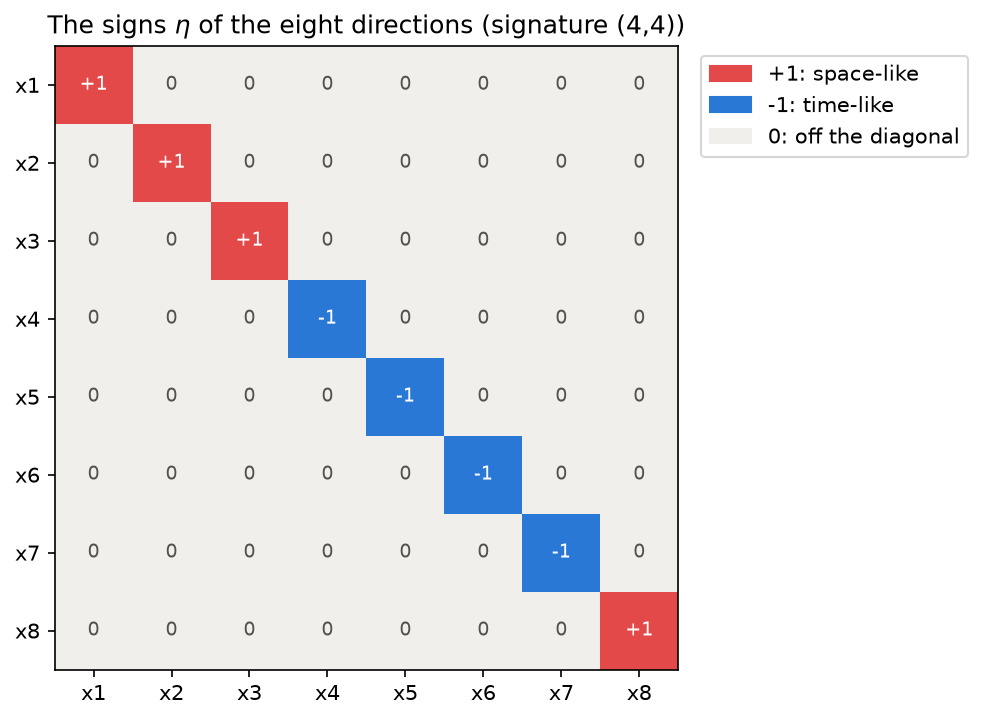

Figure 00b.1 saved as Revision/textbook/figures/00b_1_eta_heat_map.png


In [3]:
from matplotlib.colors import ListedColormap  # a colour map made of a few colours
from matplotlib.patches import Patch  # a coloured square for the legend

eta_matrix = np.diag(eta)  # 8 x 8: the signs on the diagonal, 0 elsewhere
BLUE, GREY, RED = "#2a78d6", "#f0efec", "#e34948"
colour_map = ListedColormap([BLUE, GREY, RED])  # three colours for -1, 0, +1

fig, ax = plt.subplots(figsize=(6.4, 5.4))
# vmin and vmax split the numbers into three bands: -1, 0 and +1.
ax.imshow(eta_matrix, cmap=colour_map, vmin=-1.5, vmax=1.5)
for row in range(8):
    for column in range(8):
        value = int(eta_matrix[row, column])
        text = "0" if value == 0 else f"{value:+d}"
        colour = "#52514e" if value == 0 else "white"  # readable on each colour
        ax.text(column, row, text, ha="center", va="center", color=colour,
                fontsize=9)
ax.set_xticks(range(8), labels=coordinates)  # label the columns x1 ... x8
ax.set_yticks(range(8), labels=coordinates)  # label the rows x1 ... x8
ax.grid(False)  # no grid lines across the squares
ax.set_title(r"The signs $\eta$ of the eight directions (signature (4,4))")
legend_squares = [Patch(color=RED, label="+1: space-like"),
                  Patch(color=BLUE, label="-1: time-like"),
                  Patch(color=GREY, label="0: off the diagonal")]
ax.legend(handles=legend_squares, loc="upper left", bbox_to_anchor=(1.02, 1.0))
save_figure(fig, "eta_heat_map",
            r"The signs of the author's eight directions drawn as a heat map: the "
            r"8 by 8 diagonal matrix $\eta$ with the sign of each coordinate on its "
            r"diagonal and 0 everywhere else; rows and columns are labelled by the "
            r"coordinates $x_1$ to $x_8$, and the entries are pure numbers. Red "
            r"squares are $+1$ (space-like: $x_1$, $x_2$, $x_3$, $x_8$), blue "
            r"squares $-1$ (time-like: the time $x_4$ and the extra times $x_5$, "
            r"$x_6$, $x_7$), grey squares 0. Four entries are $+1$ and four are "
            r"$-1$: the signature is (4,4).")

## 6. The author's metric, written with sympy

The next cell writes the author's metric as an exact sympy matrix. `sp.symbols`
makes the symbols $x_4$, $x_8$ and $H$ (declared positive), and
`sp.Function("a4")(x4)` makes $a_4$ an unknown function of the time $x_4$.
`sp.Rational(1, 3)` is the exact fraction $1/3$; the decimal number 0.333... would
not be exact. `sp.diag(...)` makes the diagonal matrix.

Then the cell reads the check `metric_from_vielbein_equals_SPEC` of the Revision
report Revision/theory/reports/python-field-theory.json. Its detail text lists the
eight entries of the metric as formulas, for example
`g_x1x1 = exp(2*a4(x4))*sin(6*H*x8)**(1/3)`. The cell turns each formula into a
sympy expression with `sp.sympify` and checks that the eight entries come in the
order $x_1, \dots, x_8$ and that the difference of each from our entry is exactly
zero.

In [4]:
x4, x8, H = sp.symbols("x4 x8 H", positive=True)  # time, hidden coordinate, H
a4 = sp.Function("a4")(x4)  # the metric function a4, an unknown function of x4
z = 6 * H * x8  # the combination z = 6 H x8
third = sp.Rational(1, 3)  # the exact fraction 1/3
grow = sp.exp(2 * a4) * sp.sin(z) ** third  # e^(2 a4) sin^(1/3) z
shrink = sp.exp(-2 * a4) * sp.sin(z) ** third  # e^(-2 a4) sin^(1/3) z
g = sp.diag(grow, grow, grow, -1, -shrink, -shrink, -shrink, sp.cot(z) ** 2)

THEORY_REPORT = "Revision/theory/reports/python-field-theory.json"
verdict, detail = recorded_check(THEORY_REPORT, "metric_from_vielbein_equals_SPEC")
formulas = detail.split("exactly: ", 1)[1].split("; ")  # the 8 texts "g_.. = ..."
# How sympify must read the letters of the formulas: a4 is a function, x4, x8 and
# H are our symbols.
letters = {"a4": sp.Function("a4"), "x4": x4, "x8": x8, "H": H}
labels = []  # the names g_x1x1, g_x2x2, ... in the order of the record
different = []  # the entries whose difference from ours is not zero
for k, text in enumerate(formulas):
    label, formula = text.split(" = ")  # "g_x1x1" and its formula
    labels.append(label)
    recorded = sp.sympify(formula, locals=letters)  # the text as a sympy formula
    if sp.simplify(recorded - g[k, k]) != 0:
        different.append(label)
    say(f"recorded {label} = {formula}")
in_order = [f"g_x{k}x{k}" for k in range(1, 9)]  # g_x1x1, ..., g_x8x8
check_reproduces(
    verdict == "PASS" and labels == in_order and different == [],
    "our eight entries equal the eight entries recorded by the Revision verifier",
    f"{THEORY_REPORT}, check metric_from_vielbein_equals_SPEC")

recorded g_x1x1 = exp(2*a4(x4))*sin(6*H*x8)**(1/3)
recorded g_x2x2 = exp(2*a4(x4))*sin(6*H*x8)**(1/3)
recorded g_x3x3 = exp(2*a4(x4))*sin(6*H*x8)**(1/3)
recorded g_x4x4 = -1
recorded g_x5x5 = -exp(-2*a4(x4))*sin(6*H*x8)**(1/3)
recorded g_x6x6 = -exp(-2*a4(x4))*sin(6*H*x8)**(1/3)
recorded g_x7x7 = -exp(-2*a4(x4))*sin(6*H*x8)**(1/3)
recorded g_x8x8 = cot(6*H*x8)**2
PASS our eight entries equal the eight entries recorded by the Revision verifier
     reproduces Revision/theory/reports/python-field-theory.json, check
    metric_from_vielbein_equals_SPEC


The next cell checks the signs of the eight entries numerically. It replaces $a_4$
by a plain number $a$ and $6 H x_8$ by a plain number $\zeta$, turns the eight
entries into numpy functions of $(a, \zeta)$ with `sp.lambdify`, and evaluates
them on a grid of 61 values of $a$ from $-3$ to $3$ and 79 values of $\zeta$ from
0.01 to $\pi/2 - 0.01$ (4819 points).
`np.sign` gives $+1$ for a positive number and $-1$ for a negative one. Every entry
must have the sign that the Revision record gives for its direction, at every
point.

In [5]:
a, zeta = sp.symbols("a zeta", real=True)  # plain numbers for a4 and for 6 H x8
# x8 = zeta / (6 H) makes 6 H x8 = zeta; sympy cancels the 6 H automatically.
entries = [g[k, k].subs(a4, a).subs(x8, zeta / (6 * H)) for k in range(8)]
# entry_functions[k](a, zeta) computes the entry g_kk with numpy.
entry_functions = [sp.lambdify((a, zeta), entry, "numpy") for entry in entries]

# Two arrays of shape 79 x 61: every combination of the 61 values of a and the 79
# values of zeta.
a_grid, zeta_grid = np.meshgrid(np.linspace(-3.0, 3.0, 61),
                                np.linspace(0.01, np.pi / 2 - 0.01, 79))
wrong_signs = 0  # the number of (point, entry) pairs with a wrong sign
for k in range(8):
    # np.full_like makes an array of the grid's shape; a constant entry such as
    # -1 is then repeated at every point.
    values = np.full_like(a_grid, 1.0) * entry_functions[k](a_grid, zeta_grid)
    wrong_signs += int(np.sum(np.sign(values) != eta[k]))
report("points of the grid", a_grid.size)
report("(point, entry) pairs with a sign different from eta", wrong_signs)
check_reproduces(
    wrong_signs == 0,
    "every entry has the recorded sign at all 4819 points: (+,+,+,-,-,-,-,+)",
    f"{ALGEBRA_REPORT}, check eta_in_author_order")

RESULT points of the grid = 4819
RESULT (point, entry) pairs with a sign different from eta = 0
PASS every entry has the recorded sign at all 4819 points: (+,+,+,-,-,-,-,+)
     reproduces Revision/algebra/reports/wolfram-algebra.json, check eta_in_author_order


The next cell computes the determinant of $g$ with sympy. `g.det()` multiplies the
eight diagonal entries; sympy cancels $e^{6 a_4} e^{-6 a_4} = 1$ by itself. To
print the result in terms of $z$, the cell replaces $6 H x_8$ by the plain number
$\zeta$ of the previous cell: sympy prints $\sin^2 \zeta \cot^2 \zeta$, and
`sp.trigsimp` (trigonometric simplification) writes this as $\cos^2 \zeta$. The
first check confirms, for the determinant written with $x_8$ and $H$, that the
difference from $\cos^2 z$ is exactly zero, and that the Wolfram verifier of the
field theory (the report Revision/theory/reports/wolfram-field-theory.json)
recorded PASS for the same statement, its check `sqrt_det_g_is_cos_z`. The second
check confirms that the determinant does not change with the time $x_4$: its
derivative with respect to $x_4$ is zero, although $a_4$ depends on $x_4$. The
third check reads the verdict that the Wolfram verifier of the field equations for
$a_4$ (the report Revision/field_equations_a4/reports/wolfram-a4-report.json)
recorded for its check `metric_is_SPEC_section_1`: that verifier used this same
metric.

In [6]:
determinant = g.det()  # the product of the eight diagonal entries
determinant_zeta = determinant.subs(x8, zeta / (6 * H))  # 6 H x8 replaced by zeta
say(f"det g = {determinant_zeta}")
say(f"    = {sp.trigsimp(determinant_zeta)}   (zeta stands for z = 6 H x8)")
WOLFRAM_THEORY = "Revision/theory/reports/wolfram-field-theory.json"
verdict, detail = recorded_check(WOLFRAM_THEORY, "sqrt_det_g_is_cos_z")
say(f"The Wolfram verifier recorded for sqrt_det_g_is_cos_z: {verdict}")
check_reproduces(
    sp.simplify(determinant - sp.cos(z) ** 2) == 0 and verdict == "PASS",
    "det g = cos^2 z exactly, so sqrt|det g| = cos z on 0 < z < pi/2",
    f"{WOLFRAM_THEORY}, check sqrt_det_g_is_cos_z")
check(sp.diff(determinant, x4) == 0,
      "det g does not depend on the time x4: no a4 in the volume factor")
verdict, detail = recorded_check(
    "Revision/field_equations_a4/reports/wolfram-a4-report.json",
    "metric_is_SPEC_section_1")
check(verdict == "PASS",
      "the field-equation verifier recorded PASS for metric_is_SPEC_section_1")

det g = sin(zeta)**2*cot(zeta)**2
    = cos(zeta)**2   (zeta stands for z = 6 H x8)
The Wolfram verifier recorded for sqrt_det_g_is_cos_z: PASS
PASS det g = cos^2 z exactly, so sqrt|det g| = cos z on 0 < z < pi/2
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    sqrt_det_g_is_cos_z
PASS det g does not depend on the time x4: no a4 in the volume factor
PASS the field-equation verifier recorded PASS for metric_is_SPEC_section_1


## 7. Inflation and deflation

Fix the hidden coordinate (that is, fix $z$). Then the length factor of each
direction of ordinary space is $e^{a_4}$ times the fixed number $\sin^{1/6} z$,
and that of each extra time is $e^{-a_4}$ times the same number. The next cell
draws $e^{a_4}$ and $e^{-a_4}$ for $a_4$ from 0 to 3, with a logarithmic vertical
axis, on which both are straight lines: the logarithm of $e^{a_4}$ is $a_4$ and
that of $e^{-a_4}$ is $-a_4$. It also draws the product of the three factors of
ordinary space and the three factors of the extra times,
$e^{3 a_4} \cdot e^{-3 a_4} = 1$, and checks both statements.

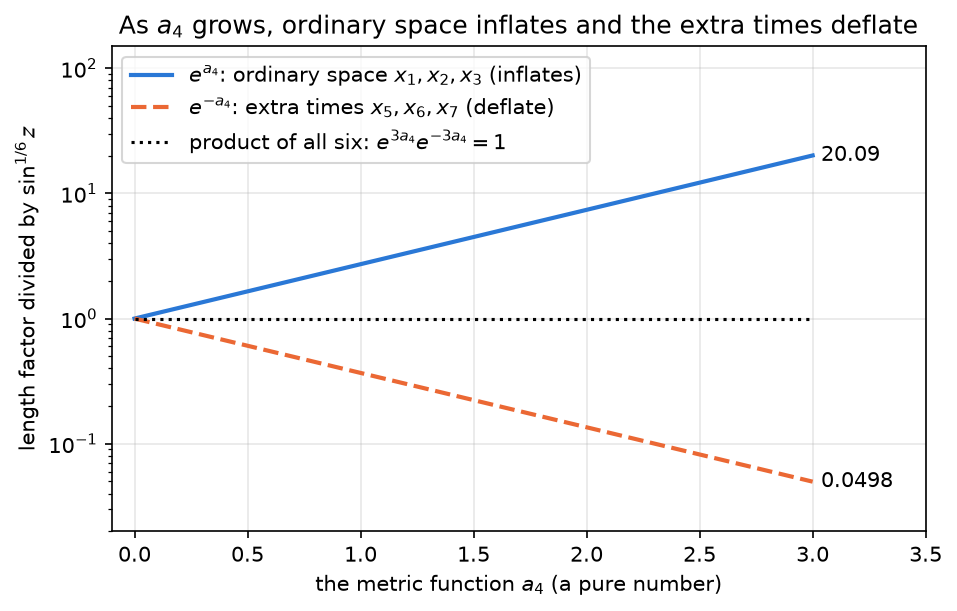

Figure 00b.2 saved as Revision/textbook/figures/00b_2_scale_factors.png
RESULT e^(a4) at a4 = 3 = 20.0855
RESULT e^(-a4) at a4 = 3 = 0.049787
PASS the product of the three inflating and three deflating factors is 1
PASS on a logarithmic axis e^(a4) and e^(-a4) are straight lines of slope +1, -1


In [7]:
a4_values = np.linspace(0.0, 3.0, 301)  # 301 values of a4 from 0 to 3
growing = np.exp(a4_values)  # the 3-space factor e^(a4)
shrinking = np.exp(-a4_values)  # the extra-time factor e^(-a4)
six_factors = growing ** 3 * shrinking ** 3  # three of each: e^(3 a4) e^(-3 a4)

ORANGE = "#eb6834"
fig, ax = plt.subplots()
ax.plot(a4_values, growing, color=BLUE, linewidth=2,
        label=r"$e^{a_4}$: ordinary space $x_1, x_2, x_3$ (inflates)")
ax.plot(a4_values, shrinking, color=ORANGE, linewidth=2, linestyle="--",
        label=r"$e^{-a_4}$: extra times $x_5, x_6, x_7$ (deflate)")
ax.plot(a4_values, six_factors, color="black", linewidth=1.5, linestyle=":",
        label=r"product of all six: $e^{3 a_4} e^{-3 a_4} = 1$")
ax.set_yscale("log")  # a logarithmic vertical axis
ax.set_xlabel(r"the metric function $a_4$ (a pure number)")
ax.set_ylabel(r"length factor divided by $\sin^{1/6} z$")
ax.set_title("As $a_4$ grows, ordinary space inflates and the extra times deflate")
# Direct labels at the right ends of the two lines (the numbers at a4 = 3).
ax.annotate(f"{growing[-1]:.2f}", (3.0, growing[-1]), xytext=(4, 0),
            textcoords="offset points", va="center")
ax.annotate(f"{shrinking[-1]:.4f}", (3.0, shrinking[-1]), xytext=(4, 0),
            textcoords="offset points", va="center")
ax.set_xlim(-0.1, 3.5)  # room on the right for the two numbers
ax.set_ylim(0.02, 150.0)  # room at the top for the legend
ax.legend(loc="upper left")
save_figure(fig, "scale_factors",
            r"The length factors of the author's metric at a fixed hidden "
            r"coordinate, divided by $\sin^{1/6} z$, against the metric function "
            r"$a_4$ from 0 to 3 (horizontal axis, a pure number; vertical axis "
            r"logarithmic, a pure number). Solid blue: $e^{a_4}$, the factor of "
            r"each direction of ordinary space, which grows to $e^3 = 20.09$; "
            r"dashed orange: $e^{-a_4}$, the factor of each extra time, which "
            r"shrinks to $e^{-3} = 0.0498$; dotted black: the product of the three "
            r"space factors and the three extra-time factors, which stays exactly "
            r"1. On the logarithmic axis both exponentials are straight lines.")
report("e^(a4) at a4 = 3", f"{growing[-1]:.4f}")
report("e^(-a4) at a4 = 3", f"{shrinking[-1]:.6f}")
check(np.max(np.abs(six_factors - 1.0)) < 1e-12,
      "the product of the three inflating and three deflating factors is 1")
check(np.max(np.abs(np.log(growing) - a4_values)) < 1e-12
      and np.max(np.abs(np.log(shrinking) + a4_values)) < 1e-12,
      "on a logarithmic axis e^(a4) and e^(-a4) are straight lines of slope +1, -1")

## 8. The eight length factors

The next cell computes all eight length factors $f_i = \sqrt{|g_{ii}|}$ from the
sympy entries made above, at the hidden coordinate $z = \pi/4$, for three values
of the metric function: $a_4 = 0$, $0.5$ and $1$. At $z = \pi/4$ we have
$\sin^{1/6}(\pi/4) = 2^{-1/12} = 0.9439$ and $\cot(\pi/4) = 1$. The cell prints
the factors as a table and draws them as bars: the bars of $x_1, x_2, x_3$ grow
with $a_4$, those of $x_5, x_6, x_7$ shrink, and those of $x_4$ and $x_8$ do not
change. The product of the eight factors is $\sqrt{|\det g|} = \cos(\pi/4) =
0.7071$ for every $a_4$. The check confirms this for the three values of $a_4$
and that the Wolfram verifier of the field equations for $a_4$ recorded PASS for
its check `sqrt_abs_det_g_is_cos_z` (the volume factor is $\cos z$ and does not
depend on $a_4$).

a4        x1      x2      x3      x4      x5      x6      x7      x8  product
0.0   0.9439  0.9439  0.9439  1.0000  0.9439  0.9439  0.9439  1.0000  0.7071
0.5   1.5562  1.5562  1.5562  1.0000  0.5725  0.5725  0.5725  1.0000  0.7071
1.0   2.5657  2.5657  2.5657  1.0000  0.3472  0.3472  0.3472  1.0000  0.7071


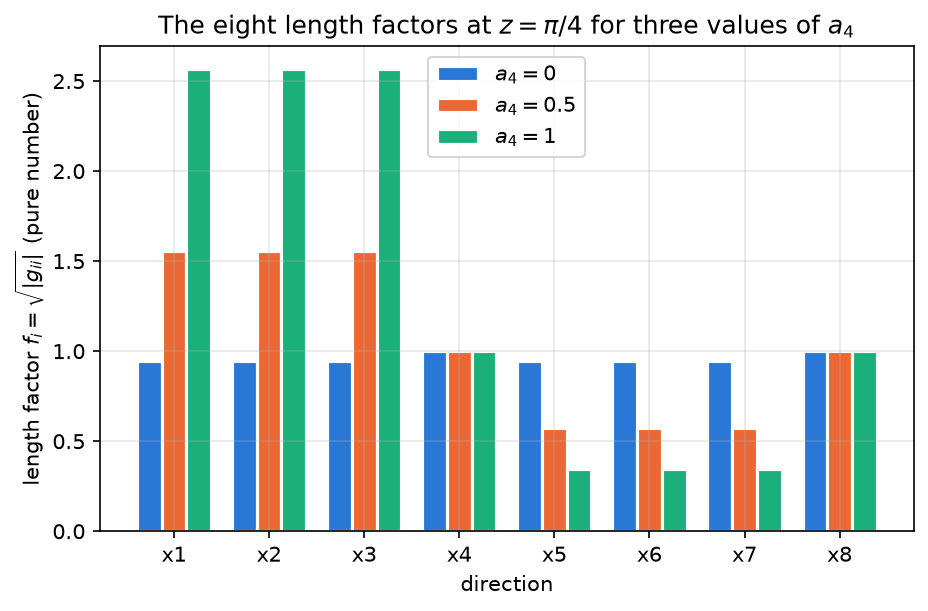

Figure 00b.3 saved as Revision/textbook/figures/00b_3_length_factors.png
PASS the product of the eight factors is cos(pi/4) = 0.7071 for a4 = 0, 0.5, 1
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    sqrt_abs_det_g_is_cos_z


In [8]:
AQUA = "#1baf7a"
z_fixed = np.pi / 4  # the hidden coordinate z = pi/4
a4_choices = [0.0, 0.5, 1.0]
factors = {}  # a4 -> the list of the eight length factors f1 ... f8
for a4_value in a4_choices:
    factors[a4_value] = [float(np.sqrt(abs(entry_functions[k](a4_value, z_fixed))))
                         for k in range(8)]

say("a4    " + "  ".join(f"{name:>6}" for name in coordinates) + "  product")
for a4_value in a4_choices:
    row = "  ".join(f"{value:6.4f}" for value in factors[a4_value])
    say(f"{a4_value:<4}  {row}  {np.prod(factors[a4_value]):.4f}")

fig, ax = plt.subplots()
positions = np.arange(8)  # one group of bars per direction
width = 0.26  # the width of one bar; three bars side by side in each group
for shift, a4_value, colour in zip((-1, 0, 1), a4_choices, (BLUE, ORANGE, AQUA)):
    # edgecolor="white" with linewidth 1.5 leaves a thin gap between the bars.
    ax.bar(positions + shift * width, factors[a4_value], width, color=colour,
           edgecolor="white", linewidth=1.5, label=f"$a_4 = {a4_value:g}$")
ax.set_xticks(positions, labels=coordinates)
ax.set_xlabel("direction")
ax.set_ylabel(r"length factor $f_i = \sqrt{|g_{ii}|}$ (pure number)")
ax.set_title(r"The eight length factors at $z = \pi/4$ for three values of $a_4$")
ax.legend(loc="upper center")
save_figure(fig, "length_factors",
            r"The eight length factors $f_i = \sqrt{|g_{ii}|}$ of the author's "
            r"metric at the hidden coordinate $z = \pi/4$ for $a_4 = 0$ (blue), "
            r"$a_4 = 0.5$ (orange) and $a_4 = 1$ (aqua); horizontal axis the "
            r"directions $x_1$ to $x_8$, vertical axis the factor (a pure number). "
            r"The factors of ordinary space $x_1$, $x_2$, $x_3$ grow from 0.94 to "
            r"2.57 as $a_4$ grows from 0 to 1, those of the extra times $x_5$, "
            r"$x_6$, $x_7$ shrink from 0.94 to 0.35, and those of the time $x_4$ "
            r"and of the hidden direction $x_8$ stay 1. The product of the eight "
            r"factors is $\cos(\pi/4) = 0.7071$ in all three cases.")
products = [float(np.prod(factors[a4_value])) for a4_value in a4_choices]
A4_REPORT = "Revision/field_equations_a4/reports/wolfram-a4-report.json"
verdict, detail = recorded_check(A4_REPORT, "sqrt_abs_det_g_is_cos_z")
check_reproduces(
    all(abs(p - np.cos(z_fixed)) < 1e-12 for p in products) and verdict == "PASS",
    "the product of the eight factors is cos(pi/4) = 0.7071 for a4 = 0, 0.5, 1",
    f"{A4_REPORT}, check sqrt_abs_det_g_is_cos_z")

## 9. The volume factor does not depend on $a_4$

The product of the eight length factors, $f_1 f_2 \cdots f_8 = \sqrt{|\det g|}$, is
the factor that turns a small coordinate box $dx_1 \, dx_2 \cdots dx_8$ into its
volume. The next cell computes it for $a_4 = 0$, $1$ and $2$ at 200 values of $z$
between 0 and $\pi/2$, and draws it together with the curve $\cos z$. The three
sets of points lie on the same curve: the inflation of ordinary space and the
deflation of the extra times cancel in the volume. (To keep the three sets of
points visible, each is drawn only at every 12th value of $z$, shifted by 4
values from the previous set.) The check compares all 600 computed values with
$\cos z$ and confirms that the Python verifier of the field theory recorded PASS
for its check `sqrt_det_g_equals_cos_z`.

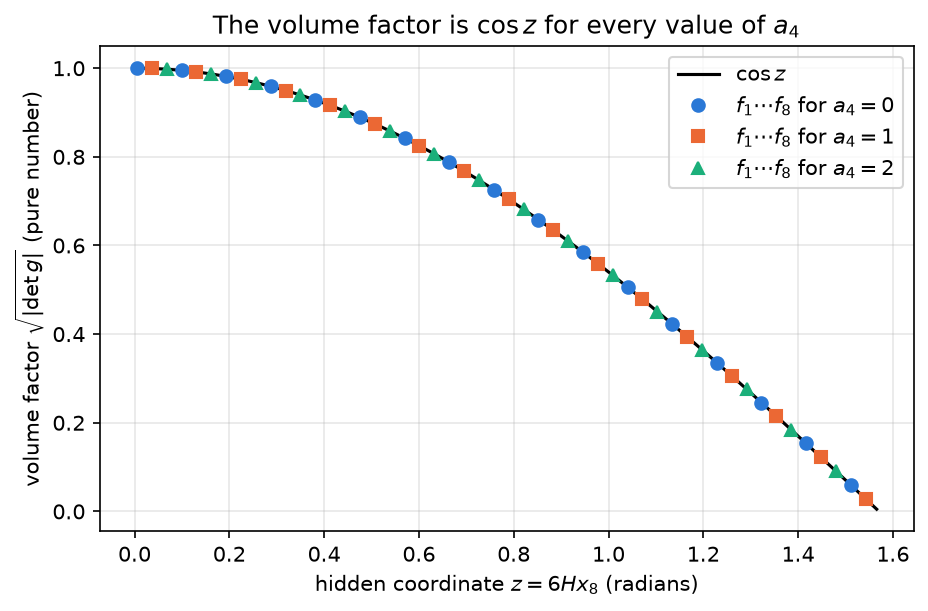

Figure 00b.4 saved as Revision/textbook/figures/00b_4_volume_factor.png
RESULT largest difference from cos z = 8.9e-16
PASS the volume factor equals cos z at 200 points for a4 = 0, 1 and 2
     reproduces Revision/theory/reports/python-field-theory.json, check
    sqrt_det_g_equals_cos_z


In [9]:
z_values = np.linspace(0.005, np.pi / 2 - 0.005, 200)  # 200 values inside (0, pi/2)
volume = {}  # a4 -> the product of the eight factors at every z
for a4_value in (0.0, 1.0, 2.0):
    product = np.ones_like(z_values)
    for k in range(8):
        values = np.full_like(z_values, 1.0) * entry_functions[k](a4_value, z_values)
        product = product * np.sqrt(np.abs(values))
    volume[a4_value] = product

fig, ax = plt.subplots()
ax.plot(z_values, np.cos(z_values), color="black", linewidth=1.5,
        label=r"$\cos z$")
markers = {0.0: ("o", BLUE), 1.0: ("s", ORANGE), 2.0: ("^", AQUA)}
for start, a4_value in enumerate((0.0, 1.0, 2.0)):
    marker, colour = markers[a4_value]
    chosen = slice(4 * start, None, 12)  # every 12th point, shifted by 4
    ax.plot(z_values[chosen], volume[a4_value][chosen], marker, color=colour,
            markersize=6, label=rf"$f_1 \cdots f_8$ for $a_4 = {a4_value:g}$")
ax.set_xlabel(r"hidden coordinate $z = 6 H x_8$ (radians)")
ax.set_ylabel(r"volume factor $\sqrt{|\det g|}$ (pure number)")
ax.set_title(r"The volume factor is $\cos z$ for every value of $a_4$")
ax.legend()
save_figure(fig, "volume_factor",
            r"The volume factor $\sqrt{|\det g|} = f_1 f_2 \cdots f_8$ of the "
            r"author's metric against the hidden coordinate $z = 6 H x_8$ from 0 to "
            r"$\pi/2$ (horizontal axis, in radians; vertical axis a pure number), "
            r"computed from the eight entries for $a_4 = 0$ (blue circles), "
            r"$a_4 = 1$ (orange squares) and $a_4 = 2$ (aqua triangles), with the "
            r"curve $\cos z$ (black line). All three sets of points lie on the "
            r"curve: the volume factor does not depend on $a_4$, because the "
            r"inflation of ordinary space and the deflation of the extra times "
            r"cancel; it falls from 1 at $z = 0$ to 0 at $z = \pi/2$.")
largest = max(float(np.max(np.abs(volume[v] - np.cos(z_values)))) for v in volume)
report("largest difference from cos z", f"{largest:.1e}")
verdict, detail = recorded_check(THEORY_REPORT, "sqrt_det_g_equals_cos_z")
check_reproduces(
    largest < 1e-12 and verdict == "PASS",
    "the volume factor equals cos z at 200 points for a4 = 0, 1 and 2",
    f"{THEORY_REPORT}, check sqrt_det_g_equals_cos_z")

## 10. The last check

The last cell checks that the four figure files of this notebook exist in the
folder Revision/textbook/figures and prints the number of checks that passed.

In [10]:
figure_names = ["00b_1_eta_heat_map.png", "00b_2_scale_factors.png",
                "00b_3_length_factors.png", "00b_4_volume_factor.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "the four figure files of this notebook exist")
all_checks_passed()

PASS the four figure files of this notebook exist
ALL 14 CHECKS PASSED (notebook 00b)


## 11. What this notebook showed

- The Revision record names the eight coordinates $x_1, \dots, x_8$ and gives their
  signs $(+, +, +, -, -, -, -, +)$: ordinary space $x_1, x_2, x_3$ and the hidden
  direction $x_8$ are space-like; the time $x_4$ and the extra times
  $x_5, x_6, x_7$ are time-like; the signature is (4,4).
- The author's metric, written with sympy, has exactly the eight entries that the
  Revision verifier recorded, and every entry has its recorded sign at every
  tested point.
- When $a_4$ grows, the length factor $e^{a_4} \sin^{1/6} z$ of ordinary space
  grows (inflation) and the length factor $e^{-a_4} \sin^{1/6} z$ of the extra times
  shrinks (deflation); if $a_4$ grows in proportion to the time, the extra times
  deflate exponentially.
- The determinant is $\det g = \cos^2 z$ exactly (PROVED by the exact computation),
  so the volume factor $\sqrt{|\det g|} = \cos z$ does not depend on $a_4$: the
  inflation and the deflation cancel in the volume.